<div style='color: #216969;
           background-color: #EAF6F6;
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
Basic LinearRegression...
<a class="anchor" id="1"></a> 

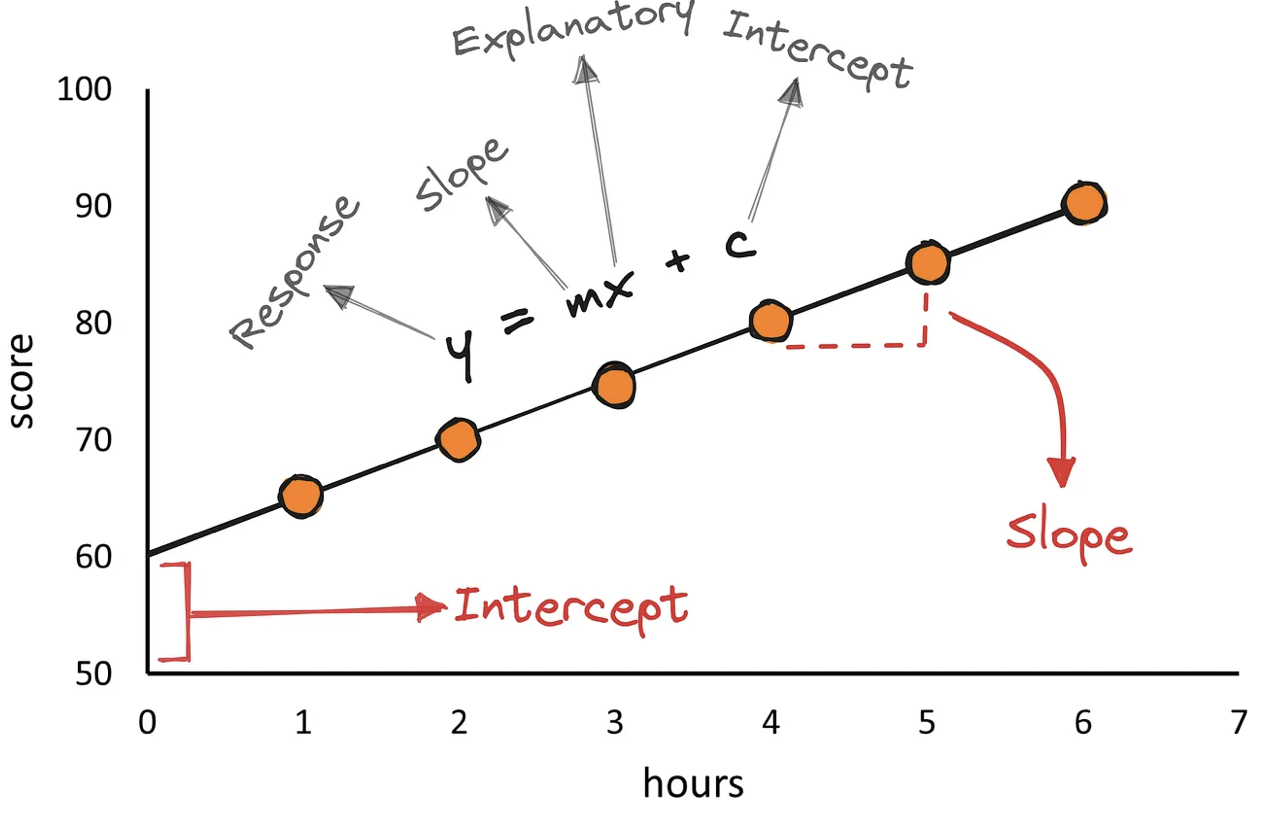

In [1]:
# dataset loading

import pandas as pd
df= pd.read_csv("../data/StudentsPerformance.csv" ) # , index_col=0)

In [2]:
df.head(3)

,gender,Group,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93


![](https://image.flaticon.com/icons/png/128/3079/3079166.png)

In [3]:
df.shape

(1000, 8)

In [4]:
# numerical features
num_features= df.select_dtypes("number")

In [5]:
# display 7 highest correlated features with SalePrice
import numpy as np
cormat=np.abs(num_features.corr()["math score"]).sort_values(ascending=False)

cormat.nlargest(7)

math score       1.000000
reading score    0.817580
writing score    0.802642
Name: math score, dtype: float64

![](https://thumbs.gfycat.com/ZealousBewitchedHapuka-size_restricted.gif)

## linear Regression
$\large \hat y= \beta_0 + \beta_1 x$

![](https://miro.medium.com/max/1280/1*fX95txC9xSwSPeP6ch2nmg.gif)

![](https://i.ibb.co/QChD6Y4/Train-test-1.jpg)

In [6]:
num_features.dtypes

math score       int64
reading score    int64
writing score    int64
dtype: object

In [7]:
from sklearn.model_selection import train_test_split
X=num_features.drop("math score",axis=1 ) #  df.OverallCond.values.reshape(-1,1)
y=num_features["math score"]  #df.SalePrice.values.reshape(-1,1)

X_train, X_test, y_train, y_test= train_test_split( X, y , test_size=.3, random_state=42)

In [8]:
import statsmodels.api as sm
lrg = sm.OLS(y_train, X_train).fit()
print(lrg.summary())

                                 OLS Regression Results                                
Dep. Variable:             math score   R-squared (uncentered):                   0.984
Model:                            OLS   Adj. R-squared (uncentered):              0.984
Method:                 Least Squares   F-statistic:                          2.164e+04
Date:                Sat, 05 Apr 2025   Prob (F-statistic):                        0.00
Time:                        23:08:08   Log-Likelihood:                         -2499.2
No. Observations:                 700   AIC:                                      5002.
Df Residuals:                     698   BIC:                                      5012.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

-  reject the null hypothesis that the coefficient is equal to 0 and conclude that x1 is an important independent variable to utilize.|

In [9]:
# linear regression
from sklearn.linear_model import LinearRegression
lreg=LinearRegression()


![](../../imgs/model.png)

In [10]:
# training the model
lreg.fit(X_train, y_train)

LinearRegression()

In [11]:
# displpay the model's coefficients
lreg.coef_ #.round(3)

array([0.59431865, 0.26474264])

In [12]:
# display the model's intercept
lreg.intercept_ #.round(3)

np.float64(6.9352420052747945)


###   $$\large \hat y= \beta_0 + \beta_i x_i$$

###  Prediction

In [13]:
X_test.sample()

,reading score,writing score
168,83,78


In [14]:
#predicting the test set results
y_pred=lreg.predict(X_test)

In [15]:
#  display the model's score
pd.options.display.precision=3
df_pred=pd.DataFrame( {"Actual_P": y_test, "Predicted_P": y_pred })
df_pred.head()

,Actual_P,Predicted_P
521,91,80.285
737,53,65.486
740,80,69.382
660,74,72.024
411,84,76.914


In [16]:
df_pred.keys()

Index(['Actual_P', 'Predicted_P'], dtype='object')

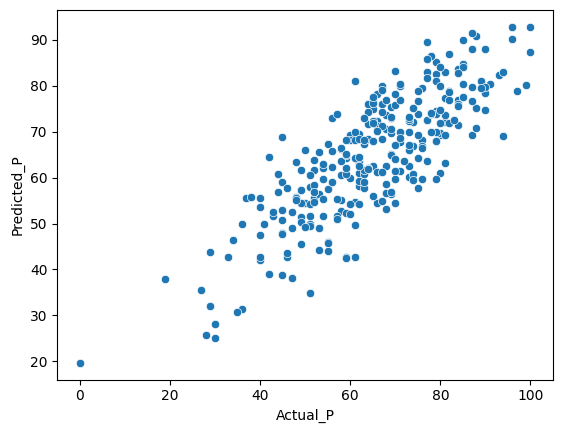

In [17]:
# graph of the model's prediction vs actual values
import seaborn as sns
# sns.set()
_=sns.scatterplot(x= "Actual_P",  y="Predicted_P", data=df_pred)

### Metrics 
![](https://i.ibb.co/wQC2qF6/ruler.png)

In [18]:
# R2  score which is a measure of how well the model is fitting the actual values
from sklearn  import metrics
f"  Score  :  {lreg.score(X_train, y_train):.3f}"


'  Score  :  0.674'

In [19]:
#  R2 for test set which measure how well the model is generalizing
f"  Score  :  {lreg.score(X_test, y_test):.3f}"

'  Score  :  0.672'

## MAE
![](https://i.imgur.com/tqnei6J.jpg)

$\Large  MAE = \frac 1 n \sum_{i=1}^N |Y_i - \hat Y_i|$

$\Large  MAE = \frac 1 n \sum_{i=1}^N |actual  - predicted|$

- MAE measures the average magnitude of the errors in a set of predictions, without considering their direction.

In [20]:
# Mean Squared Error  MSE
f"  Mean Absolute Error  MAE  :  {metrics.mean_absolute_error(y_test, y_pred):.3f}"

'  Mean Absolute Error  MAE  :  7.518'

$\Large  MSE = \frac 1 n \sum_{i=1}^N (Y_i - \hat Y_i)^2$

![](https://i.imgur.com/mLn8AeW.jpg)

In [21]:
f"  Mean Squared Error  :  {metrics.mean_squared_error(y_test, y_pred):.3f}"

'  Mean Squared Error  :  81.656'

$\Large  MSE = \sqrt {\frac 1 n \sum_{i=1}^N (Y_i - \hat Y_i)^2}$

- RMSE: 
  - average magnitude of the error.
  - RMSE should be more useful when large errors are particularly undesirable.

  
it allows us to estimate the standard deviation σ of the error for a typical single observation rather than some kind of “total error”

( it just becomes more accurate as we increase the number of observations)
- RMSE is a good way to answer the question: “How far off should we expect our model to be on its next prediction?”
$\large  Observed_{value}= predicted_{value} + \text{ predicatbly Distributed random noise with mean Zero} $
- The random noise here could be anything that our model does not capture

- Taking the square root of the average squared errors has some interesting implications for RMSE. Since the errors are squared before they are averaged, the RMSE gives a relatively high weight to large errors. This means the RMSE should be more useful when large errors are particularly undesirable.  



In [22]:
# Root Mean Squared Error  RMSE
f"  RMSE  :  {np.sqrt(metrics.mean_squared_error(y_test, y_pred)):.3f}"

'  RMSE  :  9.036'

$\Large  R^2= \frac {Variance_{predicte\_y}}{ Variance_{Actual\_y}}$

In [23]:
# R2: is the Coefficient of Determination which measures the amount of variation explained by the (least-squares) Linear Regression.
f"  R2:  :  {metrics.r2_score(y_test, y_pred):.3f}"

'  R2:  :  0.672'

- When we compare the R2 Score with the Explained Variance Score, we are basically checking the Mean Error; so if R2 = Explained Variance Score, that means: The Mean Error = Zero!

In [24]:
metrics.explained_variance_score(y_test, y_pred)

0.6718529385977134